# Analysis of isolated *Neohelice granulata* behavioral recordings

This notebook contains the Python analysis used in the C.R.A.B. project for behavioral recordings of isolated crabs. It is part of an experimental study carried out at IFIBYNE (CONICET–UBA) during Laboratorio 6, FCEyN–UBA (2025).

## Objective

Process and visualize experimental behavioral-response records generated during the C.R.A.B. study.

> **Data note:** the original experimental files are not included automatically in this repository. File references have been made repository-relative where possible; place the corresponding data files in a `data/` directory when reproducing the analysis.

## Workflow

1. Import the required Python libraries.
2. Load and organize the experimental data.
3. Process behavioral records.
4. Generate visualizations for inspection and comparison of responses.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn.objects as so

In [ ]:
df1 = pd.read_csv("Aislados1_GLMM.csv", na_values=["", " ", "  "])
df2 = pd.read_csv("Aislados2_GLMM.csv", na_values=["", " ", "  "])
df3 = pd.read_csv("Aislados3_GLMM.csv", na_values=["", " ", "  "])
df4 = pd.read_csv("Aislados4_GLMM.csv", na_values=["", " ", "  "])
aislados = pd.concat([df1,df2,df3,df4])
aislados

,Tanda,ID_Cangrejo,Condicion,Minutos,Maquina,Movimiento,Postura
0,1,P1,Perturbado,0,1,1,0
1,1,P1,Perturbado,1,0,0,0
2,1,P1,Perturbado,2,0,0,0
3,1,P1,Perturbado,3,1,1,0
4,1,P1,Perturbado,4,1,0,0
...,...,...,...,...,...,...,...
1439,4,C2,Control,356,0,0,0
1440,4,C2,Control,357,0,0,0
1441,4,C2,Control,358,1,0,0
1442,4,C2,Control,359,0,0,0


##grafico por tanda y cangrejo

In [ ]:
df = aislados[["Tanda","ID_Cangrejo","Condicion","Maquina","Movimiento"]]
df_plot = df.groupby(["Tanda","ID_Cangrejo","Condicion","Maquina"])["Movimiento"].value_counts().reset_index()
df_plot["Proporcion"] = df_plot["count"]/361
df_plot["Maquina"] = df_plot["Maquina"].map({0:  "OFF", 1: "ON"})
df_plot["Movimiento"] = df_plot["Movimiento"].map({0:  "Quietud", 1: "Movimiento"})
df_plot["ID_Cangrejo"] = df_plot["ID_Cangrejo"].map({"C1":  "CV", "P1": "PV","C2": "C2", "P2": "P2"})
df_plot = df_plot.rename(columns={'ID_Cangrejo': 'Cangrejo','Maquina': 'CRAB','Movimiento': 'Estado del cangrejo'})
df_plot


,Tanda,Cangrejo,Condicion,CRAB,Estado del cangrejo,count,Proporcion
0,1,CV,Control,OFF,Quietud,160,0.443213
1,1,CV,Control,OFF,Movimiento,88,0.243767
2,1,CV,Control,ON,Quietud,76,0.210526
3,1,CV,Control,ON,Movimiento,37,0.102493
4,1,C2,Control,OFF,Quietud,168,0.465374
...,...,...,...,...,...,...,...
58,4,PV,Perturbado,ON,Quietud,1,0.002770
59,4,P2,Perturbado,OFF,Movimiento,181,0.501385
60,4,P2,Perturbado,OFF,Quietud,73,0.202216
61,4,P2,Perturbado,ON,Movimiento,100,0.277008


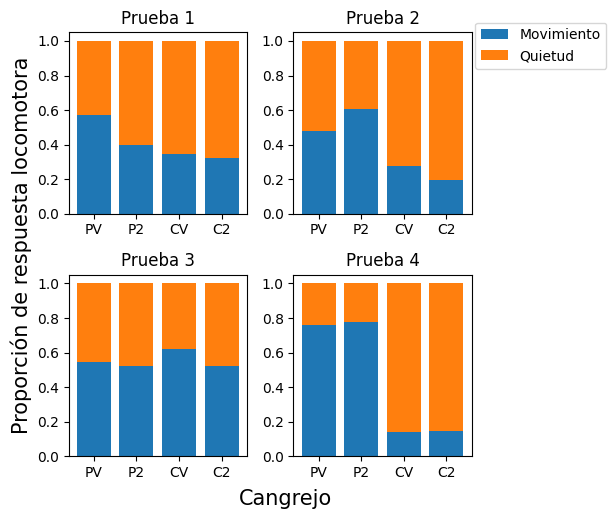

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(6, 5))
tandas = [1, 2, 3, 4]

for ax, tanda in zip(axs.flat, tandas):
    df_t = df_plot[df_plot["Tanda"] == tanda]
    # sumar proporciones por cangrejo y estado
    df_sum = (
        df_t
        .groupby(["Cangrejo", "Estado del cangrejo"])["Proporcion"]
        .sum()
        .unstack()
        .fillna(0)
    )

    orden_cangrejos = ["PV", "P2", "CV", "C2"]
    df_sum = df_sum.reindex(orden_cangrejos)

    # barras stackeadas
    bottom = None
    for estado in ["Movimiento", "Quietud"]:
        ax.bar(
            df_sum.index.astype(str),
            df_sum[estado],
            bottom=bottom,
            label=estado
        )
        bottom = df_sum[estado] if bottom is None else bottom + df_sum[estado]

    ax.set_title(f"Prueba {tanda}")


axs[0, 1].legend(loc=(1.02, 0.8))


fig.text(0.44, -0.02, "Cangrejo", ha="center", fontsize=15)
fig.text(-0.02, 0.5, "Proporción de respuesta locomotora",
         va="center", rotation="vertical", fontsize=15)

plt.tight_layout()
plt.show()


##grafico de las 4 tandas juntas


In [ ]:
df = aislados[["Tanda","ID_Cangrejo","Condicion","Maquina","Movimiento"]]
df_tot = df.groupby(["ID_Cangrejo","Condicion"])["Movimiento"].value_counts().reset_index()
df_tot["Proporcion"] = df_tot["count"]/(4*361)
df_tot["Movimiento"] = df_tot["Movimiento"].map({0:  "Quietud", 1: "Movimiento"})
df_tot["ID_Cangrejo"] = df_tot["ID_Cangrejo"].map({"C1":  "CV", "P1": "PV","C2": "C2", "P2": "P2"})
df_tot = df_tot.rename(columns={'ID_Cangrejo': 'Cangrejo','Movimiento': 'Estado del cangrejo'})

orden_cangrejos = ["PV", "P2", "CV", "C2"]


crab_mov = df_tot[(df_tot["Estado del cangrejo"]=="Movimiento")].set_index("Cangrejo").loc[orden_cangrejos].reset_index()
crab_qui = df_tot[(df_tot["Estado del cangrejo"]=="Quietud")].set_index("Cangrejo").loc[orden_cangrejos].reset_index()


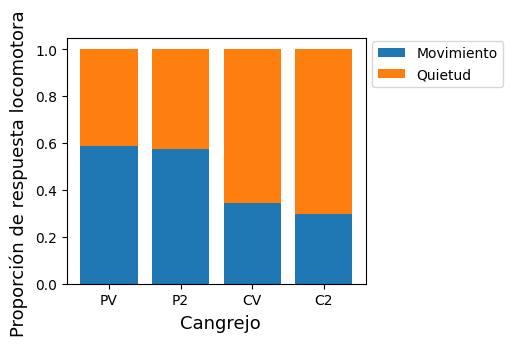

In [ ]:

fig, axs = plt.subplots(1,1, figsize=(5, 3),sharey=True)

axs.bar(crab_mov["Cangrejo"],crab_mov["Proporcion"],label="Movimiento")
axs.bar(crab_qui["Cangrejo"],crab_qui["Proporcion"],bottom=crab_mov["Proporcion"],label="Quietud")
axs.legend(loc=(1.02,0.8))

fig.text(0.4, -0.02, "Cangrejo", ha="center", fontsize=13)
fig.text(-0.02, 0.5, "Proporción de respuesta locomotora",
         va="center", rotation="vertical", fontsize=13)

plt.tight_layout()


plt.savefig('prop_4tandas.svg', format='svg')

plt.show()

##Para las 4 tandas cra ON Y OFF

In [ ]:
df = aislados[["Tanda","ID_Cangrejo","Condicion","Maquina","Movimiento"]]
df_tot = df.groupby(["ID_Cangrejo","Condicion","Maquina"])["Movimiento"].value_counts().reset_index()


df_tot["Movimiento"] = df_tot["Movimiento"].map({0:  "Quietud", 1: "Movimiento"})
df_tot["ID_Cangrejo"] = df_tot["ID_Cangrejo"].map({"C1":  "CV", "P1": "PV","C2": "C2", "P2": "P2"})
df_tot = df_tot.rename(columns={'ID_Cangrejo': 'Cangrejo','Movimiento': 'Estado del cangrejo'})


crab_on =df_tot[df_tot["Maquina"]==1]
crab_off =df_tot[df_tot["Maquina"]==0]

crab_on["Proporcion"] = crab_on["count"]/(crab_on.groupby(["Cangrejo"])["count"].sum()[0])
crab_off["Proporcion"] = crab_off["count"]/(crab_off.groupby(["Cangrejo"])["count"].sum()[0])

orden_cangrejos = ["PV", "P2", "CV", "C2"]


crab_on_mov = crab_on[(crab_on["Estado del cangrejo"]=="Movimiento")].set_index("Cangrejo").loc[orden_cangrejos].reset_index()
crab_on_qui = crab_on[(crab_on["Estado del cangrejo"]=="Quietud")].set_index("Cangrejo").loc[orden_cangrejos].reset_index()

crab_off_mov = crab_off[(crab_off["Estado del cangrejo"]=="Movimiento")].set_index("Cangrejo").loc[orden_cangrejos].reset_index()
crab_off_qui = crab_off[(crab_off["Estado del cangrejo"]=="Quietud")].set_index("Cangrejo").loc[orden_cangrejos].reset_index()



/tmp/ipython-input-2290250447.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  crab_on["Proporcion"] = crab_on["count"]/(crab_on.groupby(["Cangrejo"])["count"].sum()[0])
/tmp/ipython-input-2290250447.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crab_on["Proporcion"] = crab_on["count"]/(crab_on.groupby(["Cangrejo"])["count"].sum()[0])
/tmp/ipython-input-2290250447.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To

In [ ]:
crab_on_mov["Proporcion"]

,Proporcion
0,0.981395
1,0.953488
2,0.339535
3,0.272093


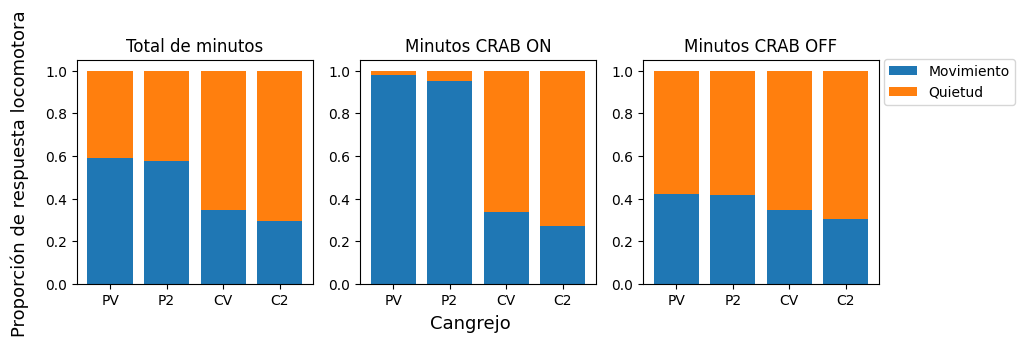

In [ ]:

fig, axs = plt.subplots(1,3, figsize=(10, 3))

axs[0].set_title(f"Total de minutos")
axs[0].bar(crab_mov["Cangrejo"],crab_mov["Proporcion"],label="Movimiento")
axs[0].bar(crab_qui["Cangrejo"],crab_qui["Proporcion"],bottom=crab_mov["Proporcion"],label="Quietud")


axs[1].set_title(f"Minutos CRAB ON")
axs[1].bar(crab_on_mov["Cangrejo"],crab_on_mov["Proporcion"])
axs[1].bar(crab_on_qui["Cangrejo"],crab_on_qui["Proporcion"],bottom=crab_on_mov["Proporcion"])


axs[2].set_title(f"Minutos CRAB OFF")
axs[2].bar(crab_off_mov["Cangrejo"],crab_off_mov["Proporcion"],label="Movimiento")
axs[2].bar(crab_off_qui["Cangrejo"],crab_off_qui["Proporcion"],bottom=crab_off_mov["Proporcion"],label="Quietud")
axs[2].legend(loc=(1.02,0.8))

fig.text(0.44, -0.02, "Cangrejo", ha="center", fontsize=13)
fig.text(-0.02, 0.5, "Proporción de respuesta locomotora",
         va="center", rotation="vertical", fontsize=13)

plt.tight_layout()

#plt.savefig('prop_4tandas_on_off.svg', format='svg')

plt.show()

##histograma


In [ ]:

df = aislados.copy()
df = df.sort_values(["ID_Cangrejo", "Tanda", "Minutos"])

df["cambio"] = (df.groupby(["ID_Cangrejo", "Tanda"])["Movimiento"].diff().fillna(0).ne(0))

df["evento"] = (df.groupby(["ID_Cangrejo", "Tanda"])["cambio"].cumsum())

quietud = df[df["Movimiento"] == 0]

duraciones = (quietud.groupby(["ID_Cangrejo", "Tanda", "Condicion", "evento"]).size().reset_index(name="Duracion"))


dur_control = duraciones[duraciones["Condicion"] == "Control"]["Duracion"]
dur_pert = duraciones[duraciones["Condicion"] == "Perturbado"]["Duracion"]

dur_pert[dur_pert == 2].describe()


,Duracion
count,277.0
mean,2.0
std,0.0
min,2.0
25%,2.0
50%,2.0
75%,2.0
max,2.0


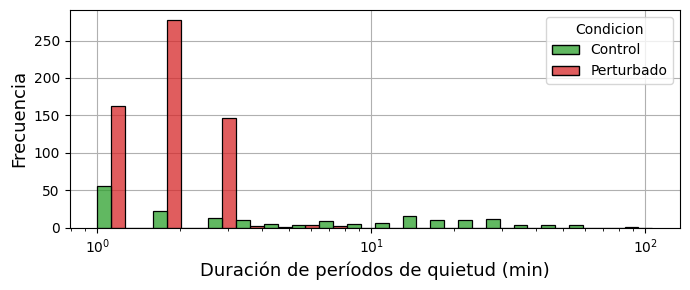

In [ ]:

plt.figure(figsize=(7, 3))
plt.gca().set_axisbelow(True)   # grilla detrás de los artistas
plt.grid()
sns.histplot(data=duraciones, x="Duracion", hue="Condicion",log_scale=True, multiple="dodge", bins=20,palette=["C2", "C3"])
plt.xlabel("Duración de períodos de quietud (min)",fontsize=13)
plt.ylabel("Frecuencia",fontsize=13)
plt.tight_layout()
plt.savefig('hist_ais.svg', format='svg')
plt.show()

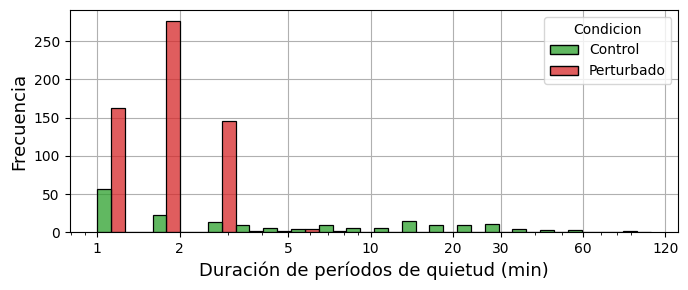

In [ ]:
import matplotlib.ticker as mticker

plt.figure(figsize=(7, 3))
plt.gca().set_axisbelow(True)
plt.grid()

ax = sns.histplot(
    data=duraciones,
    x="Duracion",
    hue="Condicion",
    log_scale=True,
    multiple="dodge",
    bins=20,
    palette=["C2", "C3"]
)

# ticks que querés mostrar (en unidades reales)
ticks_x = [1, 2, 5, 10, 20, 30, 60, 120]

ax.set_xticks(ticks_x)
ax.set_xticklabels([str(t) for t in ticks_x])

# evita notación científica
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.ticklabel_format(axis='x', style='plain')

plt.xlabel("Duración de períodos de quietud (min)", fontsize=13)
plt.ylabel("Frecuencia", fontsize=13)
plt.tight_layout()
plt.savefig('hist_ais.svg', format='svg')
plt.show()



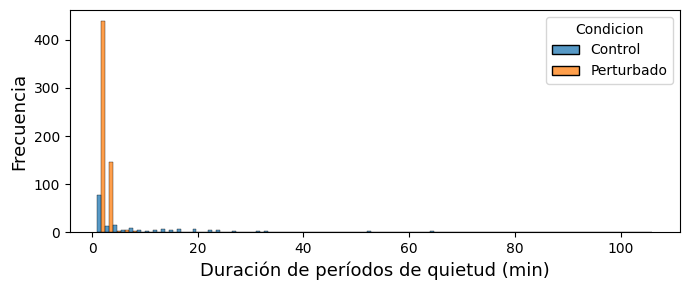

In [ ]:
plt.figure(figsize=(7, 3))
sns.histplot(data=duraciones, x="Duracion", hue="Condicion", multiple="dodge", bins=70)
plt.xlabel("Duración de períodos de quietud (min)",fontsize=13)
plt.ylabel("Frecuencia",fontsize=13)
plt.tight_layout()
plt.show()

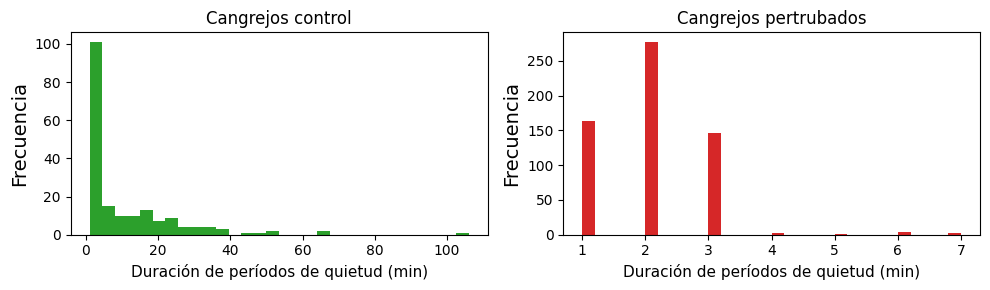

In [ ]:

fig, axs = plt.subplots(1,2, figsize=(10, 3))
axs[0].set_title("Cangrejos control")
axs[0].hist(dur_control, bins=30, alpha=1, color="C2")
axs[0].set_xlabel("Duración de períodos de quietud (min)",fontsize=11)
axs[0].set_ylabel("Frecuencia",fontsize=14)


axs[1].set_title("Cangrejos pertrubados")
axs[1].hist(dur_pert, bins=30, alpha=1, color="C3")
axs[1].set_xlabel("Duración de períodos de quietud (min)",fontsize=11)
axs[1].set_ylabel("Frecuencia",fontsize=14)
#plt.xlabel("Duración de períodos de quietud (min)")
#plt.ylabel("Frecuencia")
#plt.legend()
plt.tight_layout()
plt.show()

##posturas


In [ ]:
df_quiet = aislados[aislados["Movimiento"] == 0]
df_quiet["ID_Cangrejo"] = df_quiet["ID_Cangrejo"].map({"C1":  "CV", "P1": "PV","C2": "C2", "P2": "P2"})
df_post = (
    df_quiet
    .groupby(["ID_Cangrejo", "Condicion", "Postura"])
    .size()
    .reset_index(name="count")
)

df_post["Proporcion"] = (
    df_post["count"] /
    df_post.groupby("ID_Cangrejo")["count"].transform("sum")
)
df_retraida = df_post[df_post["Postura"]==0]
df_extendida = df_post[df_post["Postura"]==1]


#OJO CON ESTOOO
nueva_fila = pd.DataFrame([{
    "ID_Cangrejo": "CV",
    "Condicion": "Control",
    "Postura": 1,
    "count": 0,
    "Proporcion": 0.0
}])

df_extendida = pd.concat([df_extendida, nueva_fila], ignore_index=True)


orden_cangrejos = ["PV", "P2", "CV", "C2"]


df_extendida = df_extendida.set_index("ID_Cangrejo").loc[orden_cangrejos].reset_index()
df_retraida = df_retraida.set_index("ID_Cangrejo").loc[orden_cangrejos].reset_index()

/tmp/ipython-input-669526555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_quiet["ID_Cangrejo"] = df_quiet["ID_Cangrejo"].map({"C1":  "CV", "P1": "PV","C2": "C2", "P2": "P2"})


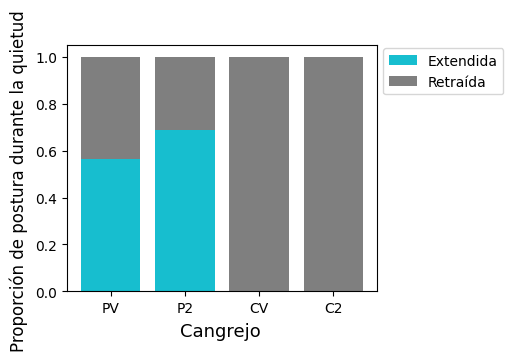

In [ ]:
fig, axs = plt.subplots(1,1, figsize=(5, 3),sharey=True)


axs.bar(df_extendida["ID_Cangrejo"],df_extendida["Proporcion"],color="C9",label="Extendida")
axs.bar(df_retraida["ID_Cangrejo"],df_retraida["Proporcion"],bottom=df_extendida["Proporcion"],color="C7",label="Retraída")
axs.legend(loc=(1.02,0.8))

fig.text(0.4, -0.02, "Cangrejo", ha="center", fontsize=13)
fig.text(-0.02, 0.5, "Proporción de postura durante la quietud",
         va="center", rotation="vertical", fontsize=12)

plt.tight_layout()
plt.show()

##Evolucion temporal


In [ ]:
df = aislados.copy()

df["ID_Cangrejo"] = df["ID_Cangrejo"].map({"C1":  "CV", "P1": "PV","C2": "C2", "P2": "P2"})
# bin de 30 minutos
df["Bin_30min"] = (df["Minutos"] // 30) * 30
df = df.sort_values(["ID_Cangrejo", "Minutos"])
df["Mov_acum"] = df.groupby("ID_Cangrejo")["Movimiento"].cumsum()

# número de observaciones acumuladas
df["N_acum"] = df.groupby("ID_Cangrejo").cumcount() + 1

# proporción acumulada
df["Prop_mov_acum"] = df["Mov_acum"] / df["N_acum"]

df_30min = (
    df.groupby(["ID_Cangrejo", "Bin_30min"])
      .last()
      .reset_index()
)
df_30min

,ID_Cangrejo,Bin_30min,Tanda,Condicion,Minutos,Maquina,Movimiento,Postura,Mov_acum,N_acum,Prop_mov_acum
0,C2,0,4,Control,29,1,0,0,67,120,0.558333
1,C2,30,4,Control,59,0,0,0,123,240,0.512500
2,C2,60,4,Control,89,0,0,0,171,360,0.475000
3,C2,90,4,Control,119,0,0,0,201,480,0.418750
4,C2,120,4,Control,149,0,0,0,260,600,0.433333
5,C2,150,4,Control,179,1,0,0,299,720,0.415278
6,C2,180,4,Control,209,1,0,0,317,840,0.377381
7,C2,210,4,Control,239,1,0,0,332,960,0.345833
8,C2,240,4,Control,269,0,0,0,346,1080,0.320370
9,C2,270,4,Control,299,0,0,0,366,1200,0.305000


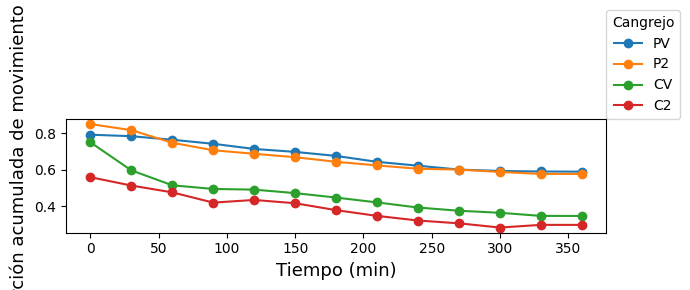

In [ ]:
ids = ["PV", "P2", "CV", "C2"]

plt.figure(figsize=(7, 3))

plt.plot(df_30min[df_30min["ID_Cangrejo"] == ids[0]]["Bin_30min"],df_30min[df_30min["ID_Cangrejo"] == ids[0]]["Prop_mov_acum"], label=ids[0], marker="o")
plt.plot(df_30min[df_30min["ID_Cangrejo"] == ids[1]]["Bin_30min"],df_30min[df_30min["ID_Cangrejo"] == ids[1]]["Prop_mov_acum"], label=ids[1], marker="o")
plt.plot(df_30min[df_30min["ID_Cangrejo"] == ids[2]]["Bin_30min"],df_30min[df_30min["ID_Cangrejo"] == ids[2]]["Prop_mov_acum"], label=ids[2], marker="o")
plt.plot(df_30min[df_30min["ID_Cangrejo"] == ids[3]]["Bin_30min"],df_30min[df_30min["ID_Cangrejo"] == ids[3]]["Prop_mov_acum"], label=ids[3], marker="o")

plt.xlabel("Tiempo (min)",fontsize=13)
plt.ylabel("Proporción acumulada de movimiento",fontsize=13)
plt.legend(title="Cangrejo",loc=(1,1))
plt.tight_layout()

plt.savefig('mov_ais.svg', format='svg')

plt.show()

In [ ]:
df = aislados.copy()

df["ID_Cangrejo"] = df["ID_Cangrejo"].map({"C1":  "CV", "P1": "PV","C2": "C2", "P2": "P2"})
# bin de 30 minutos
df["Bin_30min"] = (df["Minutos"] // 30) * 30
df = df.sort_values(["ID_Cangrejo", "Minutos"])
df["Post_acum"] = df.groupby("ID_Cangrejo")["Postura"].cumsum()

# número de observaciones acumuladas
df["N_acum"] = df.groupby("ID_Cangrejo").cumcount() + 1

# proporción acumulada
df["Prop_post_acum"] = df["Post_acum"] / df["N_acum"]

df_30min = (
    df.groupby(["ID_Cangrejo", "Bin_30min"])
      .last()
      .reset_index()
)
df_30min

,ID_Cangrejo,Bin_30min,Tanda,Condicion,Minutos,Maquina,Movimiento,Postura,Post_acum,N_acum,Prop_post_acum
0,C2,0,4,Control,29,1,0,0,1,120,0.008333
1,C2,30,4,Control,59,0,0,0,1,240,0.004167
2,C2,60,4,Control,89,0,0,0,1,360,0.002778
3,C2,90,4,Control,119,0,0,0,1,480,0.002083
4,C2,120,4,Control,149,0,0,0,1,600,0.001667
5,C2,150,4,Control,179,1,0,0,1,720,0.001389
6,C2,180,4,Control,209,1,0,0,1,840,0.001190
7,C2,210,4,Control,239,1,0,0,1,960,0.001042
8,C2,240,4,Control,269,0,0,0,1,1080,0.000926
9,C2,270,4,Control,299,0,0,0,1,1200,0.000833


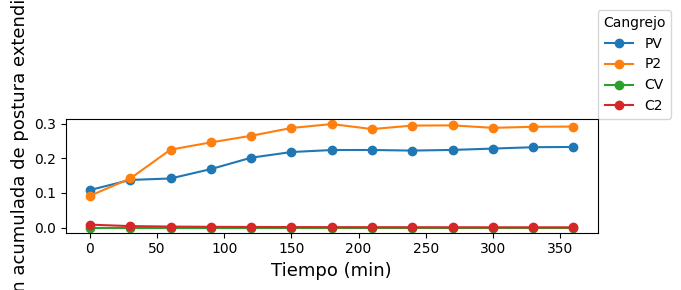

In [ ]:
ids = ["PV", "P2", "CV", "C2"]

plt.figure(figsize=(7, 3))

plt.plot(df_30min[df_30min["ID_Cangrejo"] == ids[0]]["Bin_30min"],df_30min[df_30min["ID_Cangrejo"] == ids[0]]["Prop_post_acum"], label=ids[0], marker="o")
plt.plot(df_30min[df_30min["ID_Cangrejo"] == ids[1]]["Bin_30min"],df_30min[df_30min["ID_Cangrejo"] == ids[1]]["Prop_post_acum"], label=ids[1], marker="o")
plt.plot(df_30min[df_30min["ID_Cangrejo"] == ids[2]]["Bin_30min"],df_30min[df_30min["ID_Cangrejo"] == ids[2]]["Prop_post_acum"], label=ids[2], marker="o")
plt.plot(df_30min[df_30min["ID_Cangrejo"] == ids[3]]["Bin_30min"],df_30min[df_30min["ID_Cangrejo"] == ids[3]]["Prop_post_acum"], label=ids[3], marker="o")

plt.xlabel("Tiempo (min)",fontsize=13)
plt.ylabel("Proporción acumulada de postura extendida",fontsize=13)
plt.legend(title="Cangrejo",loc=(1,1))
plt.tight_layout()

plt.savefig('post_ais.svg', format='svg')

plt.show()